## **Less Code with hierarchical multi-agent**

In [1]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    model=os.getenv("QWEN_MODEL"),
    temperature=0.4
)


## **Tools Define**
1. Medical For `PubmedQueryRun`
2. Finance for `Tavily and WIKI`

### **Pub-Med Tools**

In [2]:
from langchain_community.tools.pubmed.tool import PubmedQueryRun
pub_medical_tool = PubmedQueryRun()
result = pub_medical_tool.invoke("What causes lung cancer?")
print(result)

Published: 2025-07-02
Title: {'sup': 'R179C/+', '#text': 'Immature Acta2 smooth muscle cells cause moyamoya-like cerebrovascular lesions in mice prevented by boosting OXPHOS.'}
Copyright Information: © 2025. The Author(s).
Summary::
['R179C/+', 'R179C/+', 'SMC-R179C/+', 'SMC-R179C/+', 'R179C/+', 'SMC-R179C/+']
ACTA2 pathogenic variants altering arginine 179 cause childhood-onset strokes due to moyamoya disease (MMD)-like occlusions of the distal internal carotid arteries, but the mechanisms of pathogenesis are unknown and no preventive treatments exist. Here we show that Acta2 smooth muscle cells (SMCs) fail to fully differentiate and maintain stem cell-like features, including increased migration and glycolytic flux compared to wildtype (WT) SMCs. Increasing mitochondrial respiration with nicotinamide riboside (NR) drives differentiation and decreases migration of Acta2 SMCs. Carotid artery injury of Acta2 mice leads to premature death, intraluminal SMC accumulation leading to MMD-lik

### **TAVILY Search Tool**

In [3]:
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

from langchain_tavily import TavilySearch

finical_search_tool = TavilySearch(
    max_results=3,
    topic="general"
)

## **Wikipedia tools**

In [4]:
from langchain_community.tools.wikipedia.tool import WikipediaQueryRun
from langchain_community.utilities.wikipedia import WikipediaAPIWrapper

wiki_search_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
response = wiki_search_tool.invoke("tell me about bangladesh capital city")

print(response)


Page: Proclamation of Bangladeshi Independence
Summary: The Proclamation of Bangladeshi Independence (Bengali: বাংলাদেশের স্বাধীনতার ঘোষণাপত্র), refers to the declaration of independence of Bangladesh on 26 March 1971, at the onset of the Bangladesh Liberation War by Bangabandhu Sheikh Mujibur Rahman. On that day, Awami League leader M. A. Hannan, and the following day Major Ziaur Rahman, broadcast the message on radio on behalf of Sheikh Mujibur Rahman from the Swadhin Bangla Betar Kendra radio station in Kalurghat, Chattogram. On 10 April, the Provisional Government of Bangladesh issued a proclamation on the basis of the previous declaration and established an interim constitution for the independence movement.

Page: Assassination of Sheikh Mujibur Rahman
Summary: Sheikh Mujibur Rahman, the first president of Bangladesh, was assassinated along with most of his family members during the early hours of 15 August 1975 by a group of Bangladesh Army personnel who invaded his residence as

## **Team-1: Medical Team**

In [7]:
from pydantic import BaseModel, Field
from langgraph.graph import MessagesState
from typing import Literal
class Tema1State(MessagesState):
    next: Literal["team_1_medical_research_team", "team_1_finical_research_team", "__end__"]

In [8]:
## Team selection
from typing import Annotated

class ResearchTeamSelection(BaseModel):
    team: Annotated[Literal["team_1_medical_research_team", "team_1_finical_research_team", "FINISH"], Field(description="The selected research team based on the user question.")]
    reason: Annotated[str, Field(description="Short explanation for why this team was selected.")]

In [9]:
members = ["team_1_medical_research_team", "team_1_finical_research_team"]

In [10]:
team_selection_sys_prompt = """
    You are a supervisor, tasked with managing a conversation between the following workers: {members}.
    Given the following user request, respond with the worker to act next.
    Each worker will perform a task and respond with their results and status.
    when finished, respond with FINISH.

"""

In [11]:
from langgraph.types import Command
from langgraph.graph import StateGraph, START, END

def team_1_supervisor(state: Tema1State) -> Command[Literal["team_1_medical_research_team", "team_1_finical_research_team", "__end__"]]:
    print("--Medical Supervisor--")
    
    messages = [
        {
            "role": "system",
            "content": team_selection_sys_prompt
        },
    ] + state["messages"]
    
    print("hare-1")
    
    llm_with_structured_op = llm.with_structured_output(ResearchTeamSelection)
    response = llm_with_structured_op.invoke(messages)
    
    goto = response.team
    print(response.reason)
    
    if goto == "FINISH":
        goto = END
    
    return Command(
        update={
            "next": goto
        }, 
        goto=goto
    )
    



In [12]:
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import HumanMessage

In [18]:
medical_research_prompt = """
    You are a domain-specific autonomous research agent responsible for gathering high-quality information on a given research topic using trusted sources.

    You have access to the following tools:
    1. `wikipedia` – Use this for general knowledge, background information, financial and non-medical topics.
    2. `pubmed` – Use this for scientific research, clinical trials, diseases, medicines, and healthcare-related topics.

    Your job is to:
    - Understand the research topic provided by the user.
    - Break it down into subtopics or questions needed to fully explore the topic.
    - Decide which tool to use at each step.
    - Gather information in a structured and logical order.
    - Repeat this process until you feel you have completed the research.
    - Finally, generate a well-organized and concise **final research summary**.

    Follow this step-by-step format:
    
    Research Topic: {user_topic}

    Thought: {what subtopic should I explore first?}
    Action: {tool_name}[{tool_input}]
    Observation: {tool_output}

    Thought: {what do I need to explore next?}
    Action: {tool_name}[{tool_input}]
    Observation: {tool_output}

    ... (repeat as needed)

    Final Answer: {FINISH, well-structured research summary combining all findings}


"""


In [13]:
def team_1_medical_research_team(state: Tema1State) -> Command[Literal["team_1_supervisor"]]:
    print("--Medical Research Team--")
    
    medical_research_team = create_react_agent(
        llm,
        tools=[wiki_search_tool, pub_medical_tool],
        prompt=medical_research_prompt
    )
    
    response = medical_research_team.invoke(state)
    
    print("=====medical-research done=====")
    return Command(
        update={
            "messages": [
                HumanMessage(content=response["messages"][-1].content, name="medical_researcher_team")
            ]
        }
    )
    



In [14]:
financial_research_prompt = """
    You are a financial research specialist responsible for conducting deep and structured research on topics related to finance, economics, markets, and business.

    You have access to the following tools:
    1. `tavily` – Use this for retrieving recent or real-world financial information, news, trends, company updates, and current events.
    2. `wikipedia` – Use this for background knowledge, financial definitions, company histories, or overviews of financial terms and concepts.

    Your objective is to:
    - Analyze the research topic provided by the user.
    - Break it into logical subtopics or questions.
    - Think step-by-step to decide what needs to be known first.
    - Use the right tool for each subtask.
    - Extract reliable information and build a complete understanding.
    - Continue the process until the research feels complete.
    - Summarize your findings clearly in a final research report.

    Use this strict format:

    Research Topic: {user_topic}

    Thought: {What aspect of this topic should I explore first?}
    Action: {tool_name}[{tool_input}]
    Observation: {result from the tool}

    Thought: {What do I need to explore next?}
    Action: {tool_name}[{tool_input}]
    Observation: {result from the tool}

    ... (Repeat Thought → Action → Observation as needed)

    Final Answer: {FINISH, structured financial research summary}

"""

In [15]:
def team_1_finical_research_team(state: Tema1State) -> Command[Literal["team_1_supervisor"]]:
    print("===Finical research team===")
    
    finical_research_team = create_react_agent(
        llm,
        tools=[wiki_search_tool, pub_medical_tool],
        prompt=medical_research_prompt
    )
    
    response = finical_research_team.invoke(state)
    
    print("=====medical-research done=====")
    return Command(
        update={
            "messages": [
                HumanMessage(content=response["messages"][-1].content, name="finical_researcher_team")
            ]
        }
    )




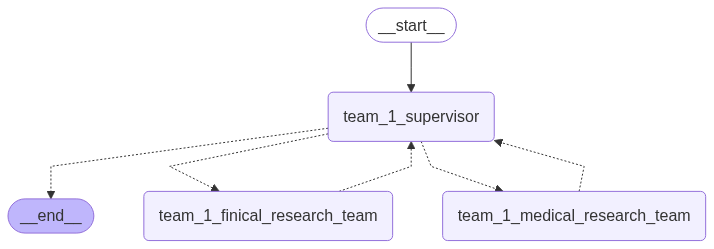

In [16]:
## team 1 sub graph state define

team_1_builder = StateGraph(Tema1State)
team_1_builder.add_node("team_1_supervisor", team_1_supervisor)
team_1_builder.add_node("team_1_medical_research_team", team_1_medical_research_team)
team_1_builder.add_node("team_1_finical_research_team", team_1_finical_research_team)

## Edges
team_1_builder.add_edge(START, "team_1_supervisor")
team_1_graph = team_1_builder.compile()
team_1_graph

In [ ]:
input = {"messages": ["Research Topic: The long-term effects of intermittent fasting"]}

for m in team_1_graph.stream(input, stream_mode="values"):
    m["messages"][-1].pretty_print()

================================ Human Message =================================

Research Topic: The long-term effects of intermittent fasting
--Medical Supervisor--
hare-1
The research topic focuses on health outcomes and physiological impacts, which requires expertise in medical science rather than financial analysis.
================================ Human Message =================================

Research Topic: The long-term effects of intermittent fasting
--Medical Research Team--
=====medical-research done=====
================================ Human Message =================================
Name: medical_researcher_team

Research Topic: The long-term effects of intermittent fasting

Thought: Begin with a general overview of intermittent fasting and its methodologies.
Action: wikipedia["Intermittent fasting"]
Observation: Intermittent fasting (IF) involves alternating periods of eating and fasting. Common methods include the 16:8 time-restricted eating, 5:2 diet, and alternate-d

In [23]:
input = {"messages": ["Research Topic: Impact of interest rate hikes on tech stocks"]}

for m in team_1_graph.stream(input, stream_mode="values"):
    m["messages"][-1].pretty_print()

================================ Human Message =================================

Research Topic: Impact of interest rate hikes on tech stocks
--Medical Supervisor--
hare-1
The topic involves financial market analysis and economic factors affecting stock performance, which falls under the financial research team's expertise.
================================ Human Message =================================

Research Topic: Impact of interest rate hikes on tech stocks
===Finical research team===
=====medical-research done=====
================================ Human Message =================================
Name: finical_researcher_team

Research Topic: Impact of interest rate hikes on tech stocks

Thought: Begin by understanding the general relationship between interest rates and stock valuations.
Action: wikipedia[Interest rate and stock market relationship]
Observation: Higher interest rates increase borrowing costs for companies, reduce present value of future earnings, and make bonds 

## **Team-2**

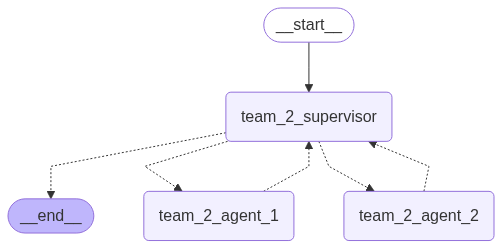

In [6]:
class Team2State(MessagesState):
    next: Literal["team_2_agent_1", "team_2_agent_2", "__end__"]
    
    
def team_2_supervisor(state: Team2State) -> Command[Literal["team_2_agent_1", "team_2_agent_2", "__end__"]]:
    pass

def team_2_agent_1(state: Team2State) -> Command[Literal["team_2_supervisor"]]:
    pass

def team_2_agent_2(state: Team2State) -> Command[Literal["team_2_supervisor"]]:
    pass

## node

team_2_builder = StateGraph(Team2State)

team_2_builder.add_node("team_2_agent_1", team_2_agent_1)
team_2_builder.add_node("team_2_agent_2", team_2_agent_2)
team_2_builder.add_node("team_2_supervisor", team_2_supervisor)

##
team_2_builder.add_edge(START, "team_2_supervisor")

team_2_graph = team_2_builder.compile()
team_2_graph

## **Define the Boss Super visor**

In [14]:
class TopState(MessagesState):
    next: Literal["team_1_graph", "team_2_graph", "__end__"]
    
def top_level_supervisor(state: TopState) -> Command[Literal["team_1_graph", "team_2_graph", "__end__"]]:
    pass


builder = StateGraph(TopState)

builder.add_node("top_level_supervisor", top_level_supervisor)
builder.add_node("team_1_graph", team_1_graph)
builder.add_node("team_2_graph", team_2_graph)
builder.add_edge(START, "top_level_supervisor")
builder.add_edge("team_1_graph", "top_level_supervisor")
builder.add_edge("team_2_graph", "top_level_supervisor")
graph = builder.compile()

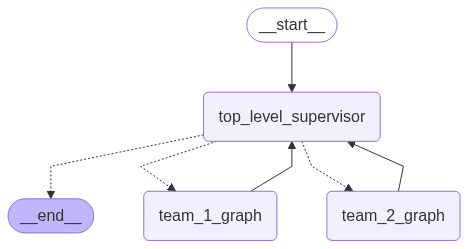

In [15]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))